In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib
import scipy.optimize as opt
matplotlib.rcParams.update({'font.size': 13})
matplotlib.rcParams['lines.linewidth'] = 2


light_green = (0.4, 0.8, 0.2)
dark_purple = (0.4, 0.3, 0.7)
raspberry_pink = (1, 0, 0.5)



# A. измерение ширины щели 
## 1. геометрическая оптика


In [58]:
#увеличение линзы
L = 136 #cm
delta_L = 0.5 #cm
b1 = 131 #cm
delta_b1 = 0.5 #cm
F2 = 3.8 #cm

#способ 1
a1 = L - b1
delta_a1 = (delta_L**2 + delta_b1**2)**0.5
print(a1, delta_a1)
gamma1 = b1/a1
delta_gamma1 = ((delta_b1/b1)**2 + (delta_a1/a1)**2)**0.5 * gamma1
print("способ 1: ", gamma1, delta_gamma1)

#способ 2
a1 = F2*b1/(b1 - F2)
delta_a1 = a1 * ((delta_b1/b1)**2 + (delta_b1/(b1 - F2))**2)**0.5
print(a1, delta_a1)
gamma2 = b1/a1
delta_gamma2 = ((delta_b1/b1)**2 + (delta_a1/a1)**2)**0.5 * gamma2
print("способ 2: ", gamma2, delta_gamma2)

5 0.7071067811865476
способ 1:  26.2 3.706588728197397
3.913522012578616 0.02144211628848596
способ 2:  33.47368421052632 0.22351589453967138


In [59]:
#измерения
dataA1 = pd.read_excel("измерения.xlsx", sheet_name="А1", skiprows=1)
dataA1

,"x, mkm*10","D1, cm","delta D1, cm",Unnamed: 3,Unnamed: 4,131,0.5
0,0,0.25,0.1,NaN,NaN,NaN,NaN
1,10,0.25,NaN,NaN,NaN,NaN,NaN
2,20,0.50,NaN,NaN,NaN,NaN,NaN
3,30,0.60,NaN,NaN,NaN,NaN,NaN
4,40,0.85,NaN,NaN,NaN,NaN,NaN
5,50,1.20,NaN,NaN,NaN,NaN,NaN
6,60,1.40,NaN,NaN,NaN,NaN,NaN
7,70,1.65,NaN,NaN,NaN,NaN,NaN
8,80,1.90,NaN,NaN,NaN,NaN,NaN
9,90,2.20,NaN,NaN,NaN,NaN,NaN


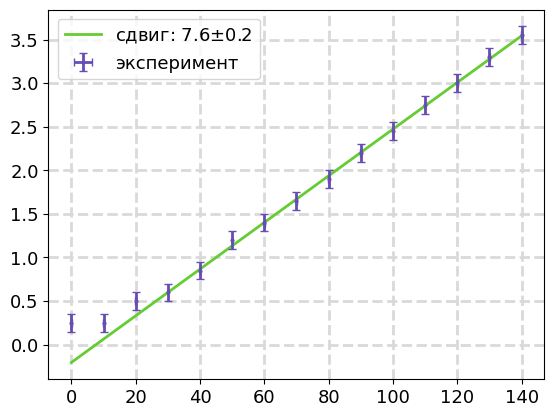

In [60]:
delta_D1 = 0.1 #cm
delta_x = 0.1 #cm

#расчет люфта

def linear(x, k, b):
    return k*x + b
popt, pcov = opt.curve_fit(linear, 
                             dataA1["x, mkm*10"].iloc[3:], 
                             dataA1["D1, cm"].iloc[3:], 
                             sigma = [delta_D1]*(len(dataA1)-3), 
                             absolute_sigma = True)
k = popt[0]
b = popt[1]
delta_k = pcov[0][0]
delta_b = pcov[1][1]

x0 = -b/k
delta_x0 = x0 * ((delta_k/k)**2+(delta_b/b)**2)**0.5

x_th = np.linspace(0, 140, 2)

plt.grid(c = (0.85, 0.85, 0.85), ls = '--', lw = 2)
plt.plot(x_th, k * x_th + b, 
         color = light_green, 
         label = f"сдвиг: {x0:.1f}" + r"$\pm$" + f"{delta_x0:.1f}")

plt.errorbar(dataA1["x, mkm*10"], dataA1["D1, cm"], 
             xerr = delta_x, yerr = delta_D1, 
             fmt = 'o', 
             capsize=3, 
             markersize = 2, 
             label = 'эксперимент',
             color = dark_purple)
#plt.ylabel()
#plt.xlabel()
plt.legend()

In [73]:
#расчет теоретической ширины и сравнение с практикой
dataA1["D, mm"] = (dataA1["x, mkm*10"] - x0)/100
delta_D = (delta_x**2 + delta_x0**2)**0.5/100
dataA1["Dл, mm"] = (dataA1["D1, cm"])/gamma1*10
dataA1["delta_Dл, mm"] = dataA1["Dл, mm"]*((delta_D1/dataA1["D1, cm"])**2 + (delta_gamma1/gamma1)**2)**0.5
dataA1_final = dataA1[["D, mm","D1, cm", "Dл, mm", "delta_Dл, mm"]].iloc[3:]
pd.set_option('display.precision', 2)
dataA1_final

,"D, mm","D1, cm","Dл, mm","delta_Dл, mm"
3,0.22,0.60,0.23,0.05
4,0.32,0.85,0.32,0.06
5,0.42,1.20,0.46,0.08
6,0.52,1.40,0.53,0.08
7,0.62,1.65,0.63,0.10
8,0.72,1.90,0.73,0.11
9,0.82,2.20,0.84,0.12
10,0.92,2.45,0.94,0.14
11,1.02,2.75,1.05,0.15
12,1.12,3.00,1.15,0.17
